<p class="mlx-kicker">Part II &middot; Architecture &middot; Chapter 2</p>

# 2. Tokens and embeddings: from one-hot symbols to subwords and patches

<dl class="mlx-meta"><div><dt>Level</dt><dd>Intermediate</dd></div><div><dt>Reading</dt><dd>about 20 min</dd></div><div><dt>Hands-on</dt><dd>about 6 min on a laptop CPU</dd></div><div><dt>You should know</dt><dd>Chapter 1, matrix multiplication, softmax and cross-entropy</dd></div></dl>

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daiyip/transformer-explained/blob/main/chapters/02-tokens/index.ipynb)

![Three generations of input representation. Each column highlights the one part that is new: one slot per symbol, a dense vector learned for each token, and a learned vocabulary of pieces (subwords for text, patches for images) that all enter the same width-d sequence.](figures/tokens-lineage.svg)

## What changed, and why it works

Before a Transformer can do anything, its input has to become a sequence of vectors of the same width `d`. This chapter asks how that happens and why one recipe now serves every modality: **why do learned vectors over subwords and patches work for every modality?** The short answer has two halves. The vectors are learned, so similar inputs end up close together and the rest of the network can generalize between them. The units are chosen from data, so each token carries a useful amount of information and sequences stay short. Figure 2.1 shows the three generations.

<div class="mlx-why">
<section class="mlx-why__card mlx-why__card--1"><p class="mlx-why__n">1 &middot; One-hot</p><h3>One symbol, one slot</h3><p><b>What changed.</b> Each character or word gets its own position in a vector of length V, set to 1 while every other position is 0. This is how symbols entered neural networks and n-gram models before 2003.</p><p><b>Why it works.</b> It is lossless and needs no training: every symbol is distinguishable. But every pair of symbols is equally far apart, so nothing learned about "king" transfers to "queen". Characters keep V tiny but make sequences long; whole words make sequences short but V huge and leave rare words with almost no data.</p><p class="mlx-why__run">Our corpus: 65 characters vs 12,631 distinct words</p></section>
<section class="mlx-why__card mlx-why__card--2"><p class="mlx-why__n">2 &middot; Learned embeddings</p><h3>A dense vector learned per token</h3><p><b>What changed.</b> Each token gets a row of d learned numbers. word2vec (Mikolov et al., 2013) learned them cheaply by predicting nearby words; today the table is just the first layer of the model, trained with everything else.</p><p><b>Why it works.</b> Multiplying a one-hot vector by a matrix selects one row, so an embedding is exactly a linear layer on one-hot inputs, stored as a lookup. Words used in similar contexts receive similar gradient updates, so their rows drift together, and whatever the network learns for one is partly shared with the others.</p><p class="mlx-why__run">Our run: cosine(thou, thee) 0.62, (romeo, juliet) 0.77, random pairs 0.13, one-hot always 0</p></section>
<section class="mlx-why__card mlx-why__card--3"><p class="mlx-why__n">3 &middot; Subwords and patches</p><h3>A learned vocabulary of pieces</h3><p><b>What changed.</b> Byte-pair encoding (Sennrich et al., 2016) builds the vocabulary by repeatedly merging the most frequent adjacent pair. Vision Transformers (Dosovitskiy et al., 2020) cut images into patches and project each patch to a vector. Both feed the same blocks.</p><p><b>Why it works.</b> Frequent strings become single tokens, rare words split into known pieces, so there is no unknown word and sequences shrink. A patch is the image counterpart: a chunk of raw signal whose linear projection is learned. Once every input is a width-d vector, the Transformer does not care where it came from.</p><p class="mlx-why__run">Our run: 1,024-token BPE 1.669 vs characters 1.886 nats per character</p></section>
</div>

Read left to right, the question moves from *how do we tell symbols apart*, to *how do we make similar symbols share what is learned*, to *what should the symbols be in the first place*. The steps below rebuild each answer and test it.

## Evolution path

| Year | Step | Level | What changed |
| --- | --- | --- | --- |
| 1990s-2000s | One-hot inputs and n-gram counts | minor | one slot per word; no notion of similarity |
| 2003 | Neural language model (Bengio et al.) | **major** | a learned feature vector per word, trained with the model |
| 2012 | Raw pixels into CNNs (AlexNet) | minor | the network learns its own image features from pixels |
| 2013 | word2vec | **major** | cheap skip-gram training gives useful vectors from raw text |
| 2016 | Byte-pair encoding for translation | **major** | a subword vocabulary learned by merging frequent pairs |
| 2018-2019 | SentencePiece, byte-level BPE | minor | tokenize raw text in any language; 256 bytes as the base alphabet, so nothing is unknown |
| 2020 | Image patches (ViT) | **major** | 16&times;16 patches, linearly projected, become tokens |
| 2022-2024 | Multimodal tokens | minor | image, audio and text tokens share one sequence |

## The lineage post-mortem: what drove each replacement?

| Replacement | Pressure that drove it | What it bought |
| --- | --- | --- |
| one-hot to learned embeddings | no sharing between similar words; huge sparse inputs | generalization across words, a compact input |
| words to subwords (BPE) | rare and unseen words; vocabulary size | no unknown tokens, a vocabulary size we choose |
| characters to subwords | long sequences and attention cost | several characters per token, more context per step |
| pixels to patches | attention cost grows with the square of sequence length | images become short token sequences for the same blocks |
| separate encoders to shared tokens | wanting one model for many modalities | one sequence, one architecture, one training loss |

Read top to bottom, the pressure moves from *representation* (what the numbers mean) to *compression* (how many tokens an input costs). Embeddings answered the first question in 2003-2013 and have barely changed since. Most of the movement after 2016 is about the second: choosing units so that each token carries a useful chunk of information, which matters because attention's cost grows with sequence length.

**Still open:** whether tokenizers can be removed altogether (byte-level models such as ByT5, and learned dynamic patching such as the Byte Latent Transformer, are close but not yet standard); how tokenization causes known failures such as miscounting letters and uneven arithmetic; and whether images are better served by discrete tokens (as in Chameleon) or by continuous patch vectors.

## Diverged branches

The evolution path follows the line today's models inherited. At a few points the field split instead: two camps made different bets on the same problem, and sometimes both bets are still alive. Each tab below is one such fork, with the two branches, why they split, and how it has played out so far.

<div class="mlx-why mlx-forks" data-label="Forks in this lineage">
<section class="mlx-why__card mlx-why__card--1 mlx-fork"><p class="mlx-why__n">Fork 1 &middot; 2016-2018</p><h3>Which subwords: BPE or Unigram?</h3><div class="mlx-fork__sides"><div class="mlx-fork__side"><p class="mlx-fork__name">Byte-pair encoding <span class="mlx-fork__state mlx-fork__state--main">mainline</span></p><p>Start from characters (or bytes) and merge the most frequent pair, again and again, until the vocabulary is full. The result is deterministic: a word always splits the same way.</p><p class="mlx-fork__who">GPT-2 onward, RoBERTa, LLaMA, most current LLMs</p></div><span class="mlx-fork__vs" aria-hidden="true">vs</span><div class="mlx-fork__side"><p class="mlx-fork__name">Unigram language model <span class="mlx-fork__state mlx-fork__state--alive">still used</span></p><p>Start from a large vocabulary and prune the pieces whose removal hurts a unigram language model least. Every segmentation has a probability, so training can sample different splits of the same word.</p><p class="mlx-fork__who">T5, ALBERT, XLNet, via SentencePiece</p></div></div><p><b>Why they split.</b> BPE is greedy. Kudo (2018) argued that a probabilistic tokenizer is more principled, and that sampling segmentations during training (subword regularization) makes a model robust to how words are split. BERT's WordPiece is a third variant, which picks each merge by likelihood rather than raw frequency.</p><p><b>How it played out.</b> Byte-level BPE became the common choice for LLMs, largely for practical reasons: with 256 bytes as its base it never meets an unknown character, and it is simple to train on huge corpora. In head-to-head tests the algorithm matters less than the vocabulary size and the data it is trained on. <strong>[likely]</strong></p></section>
<section class="mlx-why__card mlx-why__card--2 mlx-fork"><p class="mlx-why__n">Fork 2 &middot; 2021-2024</p><h3>Subword tokens, or raw bytes?</h3><div class="mlx-fork__sides"><div class="mlx-fork__side"><p class="mlx-fork__name">Subword tokens <span class="mlx-fork__state mlx-fork__state--main">mainline</span></p><p>About four characters per token, so sequences are short and attention is cheap. The price is a fixed tokenizer trained before the model.</p><p class="mlx-fork__who">nearly every production LLM</p></div><span class="mlx-fork__vs" aria-hidden="true">vs</span><div class="mlx-fork__side"><p class="mlx-fork__name">Byte-level models <span class="mlx-fork__state mlx-fork__state--rival">contender</span></p><p>No tokenizer at all: the model reads raw UTF-8 bytes. ByT5 runs a standard Transformer on bytes; the Byte Latent Transformer groups bytes into patches whose size follows how hard the next byte is to predict.</p><p class="mlx-fork__who">ByT5, Byte Latent Transformer</p></div></div><p><b>Why they split.</b> Tokenizers cause odd failures: counting the letters in a word the model sees as one token, arithmetic on numbers split at arbitrary places, and higher cost for languages that split into more tokens. Bytes avoid all of these but make sequences about four times longer, and attention cost grows with length.</p><p><b>How it played out.</b> ByT5 matched its subword twin on noisy and multilingual text but ran slower. Pagnoni et al. (2024) report that byte patches match a tokenized Llama 3 style model at 8B parameters for the same training compute. Subwords still dominate in practice; dynamic byte patching is the live alternative. <strong>[likely]</strong></p></section>
<section class="mlx-why__card mlx-why__card--3 mlx-fork"><p class="mlx-why__n">Fork 3 &middot; 2017-2024</p><h3>Images as discrete codes, or continuous patches?</h3><div class="mlx-fork__sides"><div class="mlx-fork__side"><p class="mlx-fork__name">Continuous patches <span class="mlx-fork__state mlx-fork__state--main">mainline</span></p><p>Each patch is projected to a vector, as in ViT. Vision-language models such as LLaVA project a vision encoder's outputs straight into the LLM's embedding space.</p><p class="mlx-fork__who">ViT, LLaVA, most vision-language models</p></div><span class="mlx-fork__vs" aria-hidden="true">vs</span><div class="mlx-fork__side"><p class="mlx-fork__name">Discrete image tokens <span class="mlx-fork__state mlx-fork__state--rival">contender</span></p><p>A VQ-VAE learns a codebook and turns an image into a grid of code indices, which a Transformer then models exactly like words.</p><p class="mlx-fork__who">DALL-E (2021), Chameleon</p></div></div><p><b>Why they split.</b> Discrete codes put images and text in one vocabulary, so a single next-token objective can both read and draw images. Continuous patches keep the fine detail that a quantizer throws away.</p><p><b>How it played out.</b> For reading images, continuous patches won. For drawing them, diffusion models (chapter 8) lead, while discrete-token models like Chameleon keep the appeal of one model and one loss for every modality. <strong>[likely]</strong></p></section>
</div>

## Run it yourself

The steps share this setup: the TinyShakespeare text and the chapter 1 model. Step 1 and 2 work at the level of whole words, step 3 builds a subword tokenizer and trains the chapter 1 model on it, and step 4 turns synthetic images into patch tokens. Every experiment runs on a laptop CPU.

In [1]:
# Setup: works from a checkout of the repo and on Google Colab.
import pathlib, subprocess, sys

try:
    import mlexp
except ImportError:
    root = pathlib.Path.cwd().resolve().parents[1]
    if (root / "mlexp").is_dir():
        sys.path.insert(0, str(root))
    else:  # Colab: install the shared helpers from GitHub
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/daiyip/transformer-explained"], check=True)
    import mlexp

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0)
mlexp.setup_style()
device_note = "GPU available" if torch.cuda.is_available() else "running on CPU"
print(f"torch {torch.__version__}, {device_note}")

torch 2.14.1+cu130, running on CPU


In [2]:
import collections, re, time
from mlexp.transformer import TransformerLM, PatchEmbed, VisionTransformer, Block

torch.set_num_threads(1)  # the timings quoted in the text use one CPU thread; raise this to go faster
text = mlexp.data.tiny_shakespeare()
split = int(len(text) * 0.9)  # the same 90/10 split as mlexp.load_char_corpus
train_text, val_text = text[:split], text[split:]
print(f"{len(text):,} characters; {len(train_text):,} for training, {len(val_text):,} for validation")

1,115,394 characters; 1,003,854 for training, 111,540 for validation


### Step 1 (minor): one-hot symbols

#### The idea

A network computes with numbers, so a symbol has to become a vector. The simplest choice is **one-hot**: give each of the V symbols in the vocabulary its own position, and represent a symbol by a vector of V zeros with a single 1 at its position. Statistical language models before 2003 and early neural networks used exactly this.

There are two natural vocabularies for text, and they fail in opposite ways. **Characters** give a tiny vocabulary but long sequences. **Words** give short sequences but a huge vocabulary, most of whose entries are rare. Let us count both on our corpus.

In [3]:
chars = sorted(set(text))
words = re.findall(r"[a-z']+", text.lower())  # lowercase words; punctuation dropped
word_counts = collections.Counter(words)
rare = sum(1 for c in word_counts.values() if c < 5)
print(f"characters: vocabulary {len(chars):>6,}, sequence length {len(text):>9,}")
print(f"words:      vocabulary {len(word_counts):>6,}, sequence length {len(words):>9,}")
print(f"{rare:,} of {len(word_counts):,} distinct words ({rare / len(word_counts):.0%}) appear fewer than 5 times")

val_words = re.findall(r"[a-z']+", val_text.lower())
train_vocab = set(re.findall(r"[a-z']+", train_text.lower()))
unseen = sum(w not in train_vocab for w in val_words)
print(f"{unseen / len(val_words):.1%} of validation words never occur in the training text")

characters: vocabulary     65, sequence length 1,115,394
words:      vocabulary 12,631, sequence length   204,062
9,301 of 12,631 distinct words (74%) appear fewer than 5 times
5.7% of validation words never occur in the training text


Every one-hot vector is orthogonal to every other, so the model starts with no idea that "thou" and "thee" are related. It also has no way to represent a word it never saw in training, and in a corpus this small that happens often.

#### One-hot times a matrix is a lookup

The first layer of a network multiplies its input by a weight matrix `\(W\)` of shape V &times; d. With a one-hot input, the product just selects one row of `\(W\)`. An embedding table, `nn.Embedding`, is exactly this layer, stored as a lookup so the V-wide vector of zeros is never built.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equation: an embedding is a linear layer on one-hot inputs</p><div class="mlx-eq">$$e_i^{\top} W = W_{i,:}, \qquad e_i = (0, \dots, 0, \underset{i}{1}, 0, \dots, 0) \in \{0,1\}^{V}, \quad W \in \mathbb{R}^{V \times d}$$</div><p class="mlx-eq__where">Row \(i\) of \(W\) is the embedding of token \(i\). The cost is a memory read instead of a \(V \times d\) multiply, and the gradient only touches the rows of tokens that appeared in the batch.</p></div>

In [4]:
V, d = len(word_counts), 64
emb = nn.Embedding(V, d)
ids = torch.tensor([3, 17, 3, 999])
one_hot = F.one_hot(ids, V).float()           # (4, V): mostly zeros
via_matmul = one_hot @ emb.weight             # a dense V x d multiply
via_lookup = emb(ids)                         # a row lookup
print("max difference:", (via_matmul - via_lookup).abs().max().item())
print("cosine between any two different one-hot vectors:", F.cosine_similarity(one_hot[0], one_hot[1], dim=0).item())

# The parameter story: predicting the next word from the current one.
print(f"one-hot bigram table (V x V):            {V * V:>12,} parameters")
print(f"embed then predict (V x d + d x V, d={d}): {2 * V * d:>12,} parameters")

max difference: 0.0
cosine between any two different one-hot vectors: 0.0
one-hot bigram table (V x V):             159,542,161 parameters
embed then predict (V x d + d x V, d=64):    1,616,768 parameters


A model that maps a one-hot word straight to next-word scores needs a separate number for every pair of words: about 160 million parameters for this tiny corpus, nearly all of them for pairs it never sees. Squeezing through a d-dimensional embedding cuts that by a factor of about 100. More importantly, it forces words to *share*: whatever the model learns about a direction in the 64-dimensional space applies to every word whose vector points that way. Bengio et al. (2003) made this argument and trained the first neural language model with learned word vectors. **[established]**

### Step 2 (major): learned embeddings with word2vec

#### The idea

Bengio's model learned word vectors as a by-product of a full language model, which was slow to train at the time. Mikolov et al. (2013) asked a simpler question: what is the cheapest task that still produces good vectors? Their answer, **skip-gram**, trains each word's vector to predict the words around it. The key idea is the distributional hypothesis (Harris, 1954; Firth, 1957): words that appear in similar contexts tend to have similar meanings. If two words predict the same neighbours, gradient descent pushes their vectors toward the same place.

Predicting a neighbour with a full softmax over the vocabulary is expensive, so word2vec uses **negative sampling**: for each real (word, neighbour) pair, push their dot product up, and for a few random "negative" words, push it down.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equation: skip-gram with negative sampling</p><div class="mlx-eq">$$\mathcal{L} = -\log \sigma\big(u_{o}^{\top} v_{c}\big) \;-\; \sum_{k=1}^{K} \log \sigma\big(-u_{n_k}^{\top} v_{c}\big), \qquad n_k \sim P(w)^{3/4}$$</div><p class="mlx-eq__where">\(v_c\) is the input vector of the centre word, \(u_o\) the output vector of a real neighbour, and \(n_k\) are \(K\) random words drawn in proportion to their frequency raised to the power 3/4.</p></div>

#### Minimal implementation

We keep words that occur at least 5 times, take every pair of words at most 4 positions apart as a (centre, neighbour) example, and randomly drop very frequent words such as "the" (Mikolov's subsampling), which carry little information about their neighbours.

In [5]:
vocab = [w for w, c in word_counts.most_common() if c >= 5]
stoi = {w: i for i, w in enumerate(vocab)}
word_ids = torch.tensor([stoi[w] for w in words if w in stoi])
freq = torch.tensor([word_counts[w] for w in vocab], dtype=torch.float)
keep_prob = (1e-4 / (freq / freq.sum())).sqrt().clamp(max=1.0)   # subsample frequent words
noise = freq.pow(0.75) / freq.pow(0.75).sum()                     # distribution of negative samples


class SkipGram(nn.Module):
    def __init__(self, vocab_size, dim):
        super().__init__()
        self.inp = nn.Embedding(vocab_size, dim)   # the vectors we keep
        self.out = nn.Embedding(vocab_size, dim)   # "context" vectors, used only for training
        nn.init.uniform_(self.inp.weight, -0.5 / dim, 0.5 / dim)
        nn.init.zeros_(self.out.weight)

    def forward(self, centre, neighbour, negatives):
        v = self.inp(centre)                                            # (B, d)
        pos = (v * self.out(neighbour)).sum(-1)                         # (B,)
        neg = torch.bmm(self.out(negatives), v.unsqueeze(-1)).squeeze(-1)  # (B, K)
        return -(F.logsigmoid(pos).mean() + F.logsigmoid(-neg).sum(-1).mean())


def skipgram_pairs(ids, window, g):
    ids = ids[torch.rand(len(ids), generator=g) < keep_prob[ids]]
    centre = torch.cat([ids[max(0, -o):len(ids) - max(0, o)] for o in range(-window, window + 1) if o])
    neighbour = torch.cat([ids[max(0, o):len(ids) - max(0, -o)] for o in range(-window, window + 1) if o])
    perm = torch.randperm(len(centre), generator=g)
    return centre[perm], neighbour[perm]


print(f"skip-gram vocabulary: {len(vocab):,} words")

skip-gram vocabulary: 3,330 words


In [6]:
torch.manual_seed(0)
g = torch.Generator().manual_seed(0)
sg = SkipGram(len(vocab), 64)
opt = torch.optim.Adam(sg.parameters(), lr=0.01)
start = time.time()
for epoch in range(6):
    centre, neighbour = skipgram_pairs(word_ids, window=4, g=g)
    losses = []
    for i in range(0, len(centre), 4096):
        c, o = centre[i:i + 4096], neighbour[i:i + 4096]
        negatives = torch.multinomial(noise, len(c) * 5, replacement=True, generator=g).view(-1, 5)
        loss = sg(c, o, negatives)
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())
    print(f"epoch {epoch}: {len(centre):,} pairs, loss {np.mean(losses):.3f}")
print(f"trained in {time.time() - start:.0f}s")

epoch 0: 516,084 pairs, loss 2.857


epoch 1: 516,620 pairs, loss 2.626


epoch 2: 519,684 pairs, loss 2.538


epoch 3: 516,932 pairs, loss 2.455


epoch 4: 518,348 pairs, loss 2.399


epoch 5: 517,876 pairs, loss 2.362
trained in 18s


#### Experiment: what did the vectors learn?

Nothing in the loss mentions meaning, grammar or characters in a play. If the distributional hypothesis holds, those should still show up as geometry.

<div class="mlx-box mlx-box--predict"><p class="mlx-box__label">Predict first</p><p class="mlx-predict__q">After about 30 seconds of training on 200,000 words, what will be the nearest neighbours of "romeo" and "thou"? Will they look like synonyms, like grammatical relatives, or like noise?</p><details><summary>Show what happened</summary><p>Relatives by usage, not synonyms. "romeo" sits next to juliet, rosaline, mercutio, nurse and tybalt, the people in his scenes. "thou" sits next to dost, art, thy and wilt, the words used with it. "king" sits next to edward, henry, warwick, york and richard: the history plays. A few neighbours are noise ("cords" for romeo).</p></details></div>

In [7]:
E = F.normalize(sg.inp.weight.detach(), dim=1)

def neighbours(word, k=6):
    sims = E @ E[stoi[word]]
    return [vocab[i] for i in sims.topk(k + 1).indices[1:]]

for w in ["romeo", "thou", "king", "father", "night", "good"]:
    print(f"{w:>7s}: {', '.join(neighbours(w))}")

print()
pairs = [("thou", "thee"), ("romeo", "juliet"), ("king", "queen"), ("father", "son"), ("king", "thee"), ("night", "father")]
for a, b in pairs:
    print(f"cosine({a}, {b}) = {(E[stoi[a]] @ E[stoi[b]]).item():.2f}")
rand = E[torch.randint(len(vocab), (2000,))] @ E[torch.randint(len(vocab), (2000,))].T
print(f"average cosine of random word pairs = {rand.mean().item():.2f}")

  romeo: juliet, rosaline, mercutio, nurse, tybalt, cords
   thou: dost, art, what, o, thy, wilt
   king: edward, henry, warwick, iv, york, richard
 father: son, born, daughter, charm, bade, princess
  night: this, good, lady's, sun, snow, morrow
   good: sir, exchange, you, pray, come, well

cosine(thou, thee) = 0.62
cosine(romeo, juliet) = 0.77
cosine(king, queen) = 0.56
cosine(father, son) = 0.67
cosine(king, thee) = 0.36
cosine(night, father) = 0.12
average cosine of random word pairs = 0.13


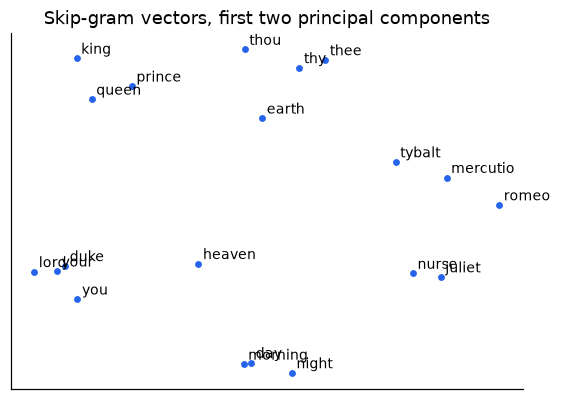

In [8]:
# Project a few words onto their top two principal directions.
group = ["romeo", "juliet", "nurse", "mercutio", "tybalt", "king", "queen", "duke", "prince", "lord",
         "thou", "thee", "thy", "you", "your", "day", "night", "morning", "heaven", "earth"]
X = E[[stoi[w] for w in group]]
X = X - X.mean(0)
_, _, Vt = torch.linalg.svd(X, full_matrices=False)
P = (X @ Vt[:2].T).numpy()
fig, ax = plt.subplots(figsize=(6, 4.2))
ax.scatter(P[:, 0], P[:, 1], s=12)
for (x, y), w in zip(P, group):
    ax.annotate(w, (x, y), xytext=(3, 3), textcoords="offset points", fontsize=9)
ax.set(title="Skip-gram vectors, first two principal components", xticks=[], yticks=[]);

#### Why it worked: a post-mortem

**Context predicts meaning, and the loss turns that into geometry.** Two words with similar neighbours receive similar gradients on their input vectors, so they end up close. Levy and Goldberg (2014) made this exact: skip-gram with negative sampling implicitly factorizes a matrix of word-context co-occurrence statistics (shifted pointwise mutual information). word2vec is a cheap, streaming way to compress co-occurrence counts. **[established]**

**What "similar" means depends on the window.** With a window of 4 on a play, "romeo" sits near the characters he shares scenes with, and "thou" sits near the verb forms that follow it ("dost", "art", "wilt") and near "thy". Its cosine with "thee" is 0.62, against 0.13 for random pairs (skip-gram vectors share a common direction, so unrelated words are not at exactly 0). These are relatives by usage, not synonyms. Small windows tend to capture syntax, large ones topic. **[established]**

**What carried over to Transformers.** The embedding table survived, but word2vec's separate pre-training did not: modern models learn the table from scratch together with everything else, and its rows end up with the same kind of structure. The deeper lesson that did carry over is that a prediction task on raw text is enough to learn useful representations, which is the whole premise of language model pre-training. **[established]** What did not carry over is the word as the unit, which step 3 replaces.

### Step 3 (major): subwords with byte-pair encoding

#### The problem before

Word vectors need a fixed vocabulary, and a fixed word vocabulary breaks in two places. Rare words get too little data for a good vector, and new words (names, typos, "unfriended") have no vector at all, so translation systems of 2015 replaced them with an `<unk>` token. Characters fix both problems but make sequences about five times longer, and attention's cost grows with the square of sequence length.

#### The idea

**Byte-pair encoding (BPE)** started as a compression algorithm (Gage, 1994). Sennrich et al. (2016) used it to build a vocabulary: start from single characters, then repeatedly find the most frequent adjacent pair of tokens in the training text and merge it into a new token. After M merges the vocabulary has (characters + M) tokens. Frequent words such as " the" become one token, and rare words fall apart into frequent pieces, so every string can still be written. GPT-2 (Radford et al., 2019) ran the same algorithm on raw bytes, so the base alphabet is 256 bytes and no input is ever unknown; SentencePiece (Kudo and Richardson, 2018) made the whole pipeline language-independent.

#### Minimal implementation

Like GPT-2, we first split the text into words with their leading space attached, and never merge across those boundaries. Counting pairs inside the distinct words, weighted by how often each word occurs, is much faster than scanning the full text.

In [9]:
PRE_SPLIT = re.compile(r" ?[A-Za-z]+| ?[0-9]+| ?[^A-Za-z0-9\s]+|\s+")


def train_bpe(text, n_merges):
    """Return the base alphabet and the list of merges, most frequent first."""
    words = {tuple(w): c for w, c in collections.Counter(PRE_SPLIT.findall(text)).items()}
    alphabet = sorted({ch for w in words for ch in w})
    merges = []
    for _ in range(n_merges):
        pairs = collections.Counter()
        for w, c in words.items():
            for pair in zip(w, w[1:]):
                pairs[pair] += c
        best = max(pairs, key=pairs.get)          # the most frequent adjacent pair
        merges.append(best)
        merged = {}
        for w, c in words.items():                # rewrite every word with the pair merged
            out, i = [], 0
            while i < len(w):
                if i + 1 < len(w) and (w[i], w[i + 1]) == best:
                    out.append(w[i] + w[i + 1]); i += 2
                else:
                    out.append(w[i]); i += 1
            merged[tuple(out)] = merged.get(tuple(out), 0) + c
        words = merged
    return alphabet, merges


class BPETokenizer:
    """Apply the first n_merges merges, lowest rank first, to each pre-split word."""

    def __init__(self, alphabet, merges):
        self.rank = {pair: r for r, pair in enumerate(merges)}
        self.tokens = alphabet + [a + b for a, b in merges]
        self.stoi = {t: i for i, t in enumerate(self.tokens)}
        self.cache = {}

    @property
    def vocab_size(self):
        return len(self.tokens)

    def split_word(self, w):
        w = list(w)
        while len(w) > 1:
            rank, i = min((self.rank.get(p, float("inf")), i) for i, p in enumerate(zip(w, w[1:])))
            if rank == float("inf"):
                break
            w[i:i + 2] = [w[i] + w[i + 1]]
        return w

    def encode(self, text):
        ids = []
        for w in PRE_SPLIT.findall(text):
            if w not in self.cache:
                self.cache[w] = [self.stoi[t] for t in self.split_word(w)]
            ids.extend(self.cache[w])
        return torch.tensor(ids)

    def decode(self, ids):
        return "".join(self.tokens[int(i)] for i in ids)

In [10]:
start = time.time()
alphabet, merges = train_bpe(train_text, 1024 - 65)   # up to a 1,024-token vocabulary
print(f"learned {len(merges)} merges in {time.time() - start:.0f}s")
print("first 12 merges:", [a + b for a, b in merges[:12]])
print("last 8 merges: ", [a + b for a, b in merges[-8:]])

sample = "Wherefore art thou Romeo? Unfriended, unparalleled."
for size in [65, 256, 1024]:
    bpe = BPETokenizer(alphabet, merges[:size - len(alphabet)])
    pieces = [bpe.tokens[i] for i in bpe.encode(sample)]
    print(f"\nvocab {size:>4}: {len(pieces)} tokens  {'|'.join(pieces)}")

learned 959 merges in 40s
first 12 merges: [' t', 'he', ' a', 'ou', ' s', ' m', 'in', ' w', 're', 'ha', ' the', 'nd']
last 8 merges:  [' why', 'ister', ' chan', ' said', 'eth', ' bid', 'uty', ' MARG']

vocab   65: 51 tokens  W|h|e|r|e|f|o|r|e| |a|r|t| |t|h|o|u| |R|o|m|e|o|?| |U|n|f|r|i|e|n|d|e|d|,| |u|n|p|a|r|a|l|l|e|l|e|d|.

vocab  256: 32 tokens  W|he|re|f|ore| a|r|t| thou| R|ome|o|?| |U|n|f|ri|e|nd|ed|,| u|n|p|ar|a|ll|e|le|d|.

vocab 1024: 21 tokens  Where|fore| art| thou| Romeo|?| |U|n|f|ri|end|ed|,| un|p|ar|all|e|led|.


Keeping only the first M merges of one run gives exactly the tokenizer you would get by training with M merges, because BPE is greedy. So one training run gives us every vocabulary size up to 1,024. Notice that the made-up word "Unfriended" is still encoded: it falls apart into pieces the tokenizer has seen.

#### Experiment: characters vs subwords for the same model

We train the chapter 1 language model (width 96, 3 blocks, 400 steps, batch 32) four times, changing only the tokenizer: characters (65 tokens) and BPE with 256, 512 and 1,024 tokens. Loss per token is not comparable across tokenizers, because a BPE token covers more text. So we convert to **nats per character**: the total loss on the validation text divided by its number of characters.

Each model reads windows of 64 tokens, so a BPE model also sees more characters of context and more characters of training text per step. To separate "better units" from "more text", a fifth run uses the 1,024-token vocabulary with windows shortened so that it sees the same number of characters as the character model.

<div class="mlx-box mlx-box--predict"><p class="mlx-box__label">Predict first</p><p class="mlx-predict__q">Will a bigger BPE vocabulary help or hurt this small model on a 1 MB corpus? And once the BPE model reads the same number of characters as the character model, does any advantage remain?</p><details><summary>Show what happened</summary><p>A bigger vocabulary helped at every size: 1.886 nats per character with characters, then 1.744, 1.722 and 1.669 with 256, 512 and 1,024 BPE tokens. With windows cut to the same 64 characters, the 1,024-token model still reached 1.703, so most of its advantage (0.18 of 0.22 nats) did not come from seeing more text.</p></details></div>

In [11]:
lm_results, histories = {}, {}
configs = [("characters", 65, 64), ("BPE 256", 256, 64), ("BPE 512", 512, 64), ("BPE 1024", 1024, 64)]
for name, size, block in configs:
    bpe = BPETokenizer(alphabet, merges[:size - len(alphabet)])
    tr, va = bpe.encode(train_text), bpe.encode(val_text)
    chars_per_token = len(val_text) / len(va)
    torch.manual_seed(0)
    model = TransformerLM(bpe.vocab_size, dim=96, n_layers=3, n_heads=4)
    start = time.time()
    h = mlexp.train_lm(model, tr, va, steps=400, block_size=block, eval_every=100, log=False)
    histories[name] = {**h, "val": [v / chars_per_token for v in h["val"]]}
    lm_results[name] = (size, chars_per_token, h["val"][-1], h["val"][-1] / chars_per_token)
    print(f"{name:10s} {len(tr):>9,} train tokens  {chars_per_token:.2f} chars/token  "
          f"loss {h['val'][-1]:.3f}/token = {lm_results[name][3]:.3f}/char  ({time.time() - start:.0f}s)")

characters 1,003,854 train tokens  1.00 chars/token  loss 1.886/token = 1.886/char  (52s)


BPE 256      543,611 train tokens  1.81 chars/token  loss 3.148/token = 1.744/char  (49s)


BPE 512      456,785 train tokens  2.09 chars/token  loss 3.601/token = 1.722/char  (51s)


BPE 1024     389,874 train tokens  2.36 chars/token  loss 3.945/token = 1.669/char  (60s)


BPE 1024, 27-token windows: 64 characters per window, loss 1.703/char
model parameters: characters 344,928, BPE 1024 529,056


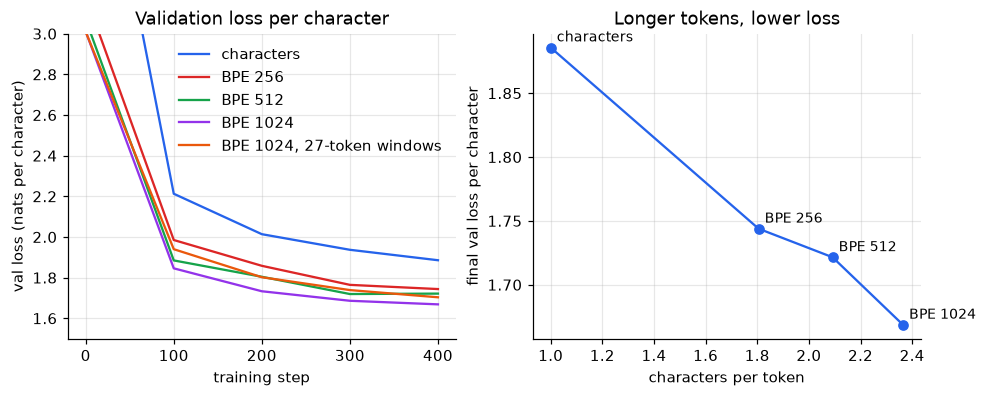

In [12]:
# Control: the 1,024-token model with windows shortened to cover about 64 characters,
# so it sees the same context and the same amount of text per step as the character model.
bpe = BPETokenizer(alphabet, merges[:1024 - len(alphabet)])
tr, va = bpe.encode(train_text), bpe.encode(val_text)
cpt = len(val_text) / len(va)
block = round(64 / cpt)
torch.manual_seed(0)
model = TransformerLM(bpe.vocab_size, dim=96, n_layers=3, n_heads=4)
h = mlexp.train_lm(model, tr, va, steps=400, block_size=block, eval_every=100, log=False)
name = f"BPE 1024, {block}-token windows"
histories[name] = {**h, "val": [v / cpt for v in h["val"]]}
lm_results[name] = (1024, cpt, h["val"][-1], h["val"][-1] / cpt)
print(f"{name}: {block * cpt:.0f} characters per window, loss {lm_results[name][3]:.3f}/char")
print(f"model parameters: characters {mlexp.count_params(TransformerLM(65, dim=96, n_layers=3, n_heads=4)):,}, "
      f"BPE 1024 {mlexp.count_params(model):,}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))
mlexp.plot_histories(histories, "Validation loss per character", ax=ax1)
ax1.set(ylabel="val loss (nats per character)", ylim=(1.5, 3.0))
names = [n for n in lm_results if not n.startswith("BPE 1024,")]
ax2.plot([lm_results[n][1] for n in names], [lm_results[n][3] for n in names], marker="o")
for n in names:
    ax2.annotate(n, (lm_results[n][1], lm_results[n][3]), xytext=(4, 4), textcoords="offset points", fontsize=9)
ax2.set(xlabel="characters per token", ylabel="final val loss per character", title="Longer tokens, lower loss");

#### Why it worked: a post-mortem

**Subwords win here, and most of the win is not extra context.** Loss per character falls steadily as the vocabulary grows from 65 to 1,024 tokens (1.886 to 1.669). When the BPE model is limited to the same 64 characters per window, and so to the same amount of text per step, it still reaches 1.703. About 0.18 of the 0.22 nats of improvement survives the control. **[likely]** for this setting: the ranking and the control both held in all three seeds we ran, at a fixed 400 steps.

**The mechanism: spelling is moved out of the model.** A character model has to predict " thou" as five separate decisions, four of which are nearly certain once the first is made, and each one costs a full pass through the network. BPE folds those easy, within-word predictions into the tokenizer, so the network's fixed compute per position goes to the harder choices between words, and each attention window covers more text. Some studies find that compression (characters per token) tracks downstream quality, though others show it is not the whole story (Schmidt et al., 2024). **[likely]**

**Caveats.** The 1,024-token model has more parameters (529,056 against 344,928), almost all of them in the larger embedding and output layers, which do no extra computation per token. The trend also cannot continue forever on a 1 MB corpus: with a much larger vocabulary, many tokens would be rare and their rows poorly trained, the same problem that sank word-level vocabularies. Production models use 32,000 to 200,000 tokens because they train on trillions of tokens. **[likely]**

**Why BPE won the vocabulary contest.** BPE is not the only subword method. WordPiece (used by BERT) merges by likelihood rather than raw frequency, and the unigram model in SentencePiece (Kudo, 2018) starts from a large vocabulary and prunes it. They give similar results; BPE won by being simple, fast and deterministic, and byte-level BPE added the guarantee that any input, in any language or encoding, can be represented. **[likely]**

**What it costs.** The tokenizer is trained separately and frozen, so the model never sees the characters inside a token. That is why language models are poor at counting letters in a word or reversing strings, and why arithmetic depends on how numbers happen to be split (Llama 3 and GPT-4 split digits into groups of at most three for this reason). Languages under-represented in the tokenizer's training data need more tokens per word, so they cost more and fit less into the context. **[established]**

### Step 4 (major): image patches as tokens

#### The idea

AlexNet (2012) fed raw pixels to a convolutional network, which learned its own features layer by layer. Feeding pixels directly to a Transformer does not work: a 224 &times; 224 image is 50,176 pixels, and attention over that many tokens is far too expensive. The Vision Transformer (Dosovitskiy et al., 2020) borrowed the subword idea: cut the image into 16 &times; 16 patches, flatten each patch and project it to width d with one learned matrix. A 224-pixel image becomes 196 tokens, the length of a paragraph.

The patch projection is the image counterpart of the embedding table. A word embedding maps a one-hot vector through a matrix; a patch embedding maps a vector of raw pixel values through a matrix. In code it is a convolution whose kernel size equals its stride, so the windows do not overlap.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equation: the patch embedding</p><div class="mlx-eq">$$z_j = W\,\mathrm{vec}(x_j) + b, \qquad x_j \in \mathbb{R}^{C \times P \times P}, \quad W \in \mathbb{R}^{d \times C P^2}$$</div><p class="mlx-eq__where">\(x_j\) is the \(j\)-th non-overlapping \(P \times P\) patch of an image with \(C\) channels. An \(H \times W\) image gives \(HW / P^2\) tokens. This is a convolution with kernel size and stride both equal to \(P\).</p></div>

#### Minimal implementation

`mlexp.transformer.PatchEmbed` is a strided convolution. We check that it equals "cut into patches, flatten, multiply by a matrix".

In [13]:
pe = PatchEmbed(patch=8, channels=3, dim=16)
images = torch.randn(2, 3, 32, 32)
patches = images.unfold(2, 8, 8).unfold(3, 8, 8)           # (B, C, 4, 4, 8, 8): a 4 x 4 grid of 8 x 8 patches
patches = patches.permute(0, 2, 3, 1, 4, 5).reshape(2, 16, 3 * 8 * 8)  # (B, 16 patches, 192 numbers each)
W = pe.proj.weight.reshape(16, -1)                          # the conv kernel, seen as a 16 x 192 matrix
manual = patches @ W.T + pe.proj.bias
print("conv output:", tuple(pe(images).shape), " manual output:", tuple(manual.shape))
print("max difference:", (manual - pe(images)).abs().max().item())

conv output: (2, 16, 16)  manual output: (2, 16, 16)
max difference: 8.344650268554688e-07


#### Experiment: how big should a patch be?

Patch size plays the role of vocabulary size. Small patches give many tokens that each carry little; large patches give few tokens that each carry a lot. We generate 32 &times; 32 images of four shapes (circle, square, triangle, cross) with random size, position and colour on a noisy background, and train the chapter 1 Vision Transformer (width 64, 2 blocks, 300 steps) with patches of 4, 8 and 16 pixels.

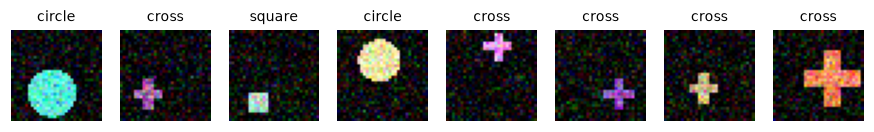

In [14]:
def make_shapes(n, size=32, seed=0):
    """Circles, squares, triangles and crosses at random position, size and colour, on noise."""
    g = torch.Generator().manual_seed(seed)
    yy, xx = torch.meshgrid(torch.arange(size), torch.arange(size), indexing="ij")
    images, labels = torch.zeros(n, 3, size, size), torch.randint(4, (n,), generator=g)
    for i in range(n):
        r = 4 + torch.rand(1, generator=g).item() * 6
        cx, cy = (r + torch.rand(2, generator=g) * (size - 2 * r)).tolist()
        dx, dy = xx - cx, yy - cy
        mask = [dx**2 + dy**2 <= r**2,
                (dx.abs() <= 0.8 * r) & (dy.abs() <= 0.8 * r),
                (dy <= 0.8 * r) & (dy >= -r) & (dx.abs() <= 0.55 * (dy + r)),
                ((dx.abs() <= 0.3 * r) & (dy.abs() <= r)) | ((dy.abs() <= 0.3 * r) & (dx.abs() <= r))][labels[i]]
        colour = torch.rand(3, 1, 1, generator=g) * 0.7 + 0.3
        images[i] = 0.15 * torch.randn(3, size, size, generator=g) + mask.float() * colour
    return images, labels


X_train, y_train = make_shapes(4000, seed=0)
X_test, y_test = make_shapes(1000, seed=1)
fig, axes = plt.subplots(1, 8, figsize=(10, 1.5))
for ax, img, lab in zip(axes, X_train, y_train):
    ax.imshow(img.permute(1, 2, 0).clamp(0, 1)); ax.set_title(["circle", "square", "triangle", "cross"][lab], fontsize=9); ax.axis("off")

In [15]:
vit_results = {}
for patch in [4, 8, 16]:
    torch.manual_seed(0)
    model = VisionTransformer(n_classes=4, image=32, patch=patch, dim=64, n_layers=2, n_heads=4)
    opt = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=0.05)
    g = torch.Generator().manual_seed(0)
    start = time.time()
    for step in range(300):
        idx = torch.randint(len(X_train), (64,), generator=g)
        loss = F.cross_entropy(model(X_train[idx]), y_train[idx])
        opt.zero_grad(); loss.backward(); opt.step()
    with torch.no_grad():
        acc = (model(X_test).argmax(-1) == y_test).float().mean().item()
    vit_results[patch] = (acc, time.time() - start)
    print(f"patch {patch:2d}: {(32 // patch) ** 2:3d} tokens, {3 * patch * patch:4d} numbers per patch, "
          f"test accuracy {acc:.1%}, {vit_results[patch][1]:.0f}s")

patch  4:  64 tokens,   48 numbers per patch, test accuracy 87.9%, 27s


patch  8:  16 tokens,  192 numbers per patch, test accuracy 84.1%, 7s


patch 16:   4 tokens,  768 numbers per patch, test accuracy 50.2%, 4s


Patches of 4 pixels (64 tokens) reach 87.9% test accuracy, 8 pixels (16 tokens) 84.1%, and 16 pixels (4 tokens) only 50.2%, against 25% for guessing. With 16-pixel patches, each token has to squeeze 768 pixel values into 64 numbers through one linear map, and most shapes are cut across patch boundaries, so the model must reassemble them from only four vectors. Across three seeds, though, 4- and 8-pixel patches end up level (87.4% and 87.2% on average; the 8-pixel run here is the unlucky one), so the four times as many tokens, and 27 s against 7 s of training, buy nothing on images this simple. Only 16-pixel patches clearly lose. This mirrors the tokenizer experiment. There, longer units gave shorter sequences and a better model; here the images and the model are small enough that large patches lose information the model needs. In both cases the unit is a choice that trades information per token against sequence length. **[likely]**

#### One sequence for every modality

Once text and images are both width-d vectors, nothing stops us from putting them in the same sequence. This is the idea behind multimodal models from Flamingo and PaLI (2022) to Chameleon and GPT-4o (2024): image tokens and text tokens are concatenated and processed by the same blocks. Below, 16 patch tokens and the 16 subword tokens of a short caption pass through one Transformer block together.

In [16]:
d = 64
text_embed = nn.Embedding(bpe.vocab_size, d)
patch_embed = PatchEmbed(patch=8, channels=3, dim=d)
block = Block(d, n_heads=4, causal=False, rope=False)

image_tokens = patch_embed(X_test[:1])                                        # (1, 16, 64)
text_tokens = text_embed(bpe.encode("a red circle on a noisy background")[None])  # (1, T, 64)
sequence = torch.cat([image_tokens, text_tokens], dim=1)
print("image tokens", tuple(image_tokens.shape), "+ text tokens", tuple(text_tokens.shape),
      "->", tuple(block(sequence).shape))

image tokens (1, 16, 64) + text tokens (1, 16, 64) -> (1, 32, 64)


#### Why it worked: a post-mortem

**A patch is a token because attention needs short sequences, not because patches are meaningful.** Unlike a subword, a 16 &times; 16 patch has no special status in an image; it is a cheap way to make sequences short enough for attention. The Transformer then has to learn the structure a CNN gets for free (locality, translation invariance), which is why ViT needed very large datasets to match CNNs at the time (Dosovitskiy et al., 2020). **[established]**

**The patch size is a compute knob.** Halving the patch size quadruples the number of tokens, and attention's cost grows faster than that. Modern vision models therefore tune patch size with model size and resolution, and some (such as NaViT) mix resolutions in one batch. **[established]**

**Why one recipe works for every modality.** Every generation in this chapter does the same two things: choose a unit that carries a reasonable amount of information, and map it linearly to a learned vector. The embedding layer is the only modality-specific part; everything after it treats a sequence of vectors the same way, whatever produced them. That is the practical reason one architecture now handles text, images, audio and actions. **[likely]** Whether shared tokens also lead to shared *understanding* across modalities, rather than separate skills in one network, is still debated. **[speculative]**

## Across three seeds

The numbers on this page come from one run, seed 0. We reran the whole notebook twice more with every random seed shifted by 1 and by 2, which changes the initial weights, the batches and the evaluation samples (the `Seed runs` workflow in the repository does this for any chapter). A gap between two runs means something only when it is clearly larger than their spread.

| Run | This page (seed 0) | Mean ± sd, 3 seeds | Seeds 0 / 1 / 2 |
| --- | --- | --- | --- |
| characters, nats per character | 1.886 | 1.887 ± 0.013 | 1.886 / 1.900 / 1.875 |
| BPE 256 | 1.744 | 1.742 ± 0.003 | 1.744 / 1.742 / 1.739 |
| BPE 512 | 1.722 | 1.714 ± 0.010 | 1.722 / 1.702 / 1.717 |
| BPE 1,024 | 1.669 | 1.658 ± 0.010 | 1.669 / 1.657 / 1.649 |
| BPE 1,024, same 64 characters per window | 1.703 | 1.711 ± 0.009 | 1.703 / 1.710 / 1.720 |
| patch 4, test accuracy | 87.9% | 87.4% ± 0.6% | 87.9% / 86.7% / 87.7% |
| patch 8, test accuracy | 84.1% | 87.2% ± 2.7% | 84.1% / 88.2% / 89.3% |
| patch 16, test accuracy | 50.2% | 47.8% ± 2.1% | 50.2% / 46.4% / 46.8% |

The tokenizer results held in every seed: each larger vocabulary was better, and the same-characters control kept most of the gain. Among the patch sizes only the 16-pixel loss is real; 4 and 8 pixels are tied.

## Recap

<div class="mlx-box mlx-box--objectives"><p class="mlx-box__label">Recap</p><p>You should now be able to:</p><ol><li>Show that an embedding table is a linear layer on one-hot inputs, and explain why it generalizes where one-hot does not.</li><li>Train a skip-gram model with negative sampling and read its nearest neighbours.</li><li>Implement a BPE tokenizer and compare tokenizers fairly with loss per character.</li><li>Write a patch embedding as a strided convolution and explain how patch size trades accuracy for sequence length.</li></ol></div>

<div class="mlx-box mlx-box--check"><p class="mlx-box__label">Check your understanding</p><details><summary>Why is <code>nn.Embedding(V, d)</code> the same as a linear layer applied to one-hot vectors?</summary><p>Multiplying a one-hot vector for token i by a V &times; d matrix selects row i. The lookup returns that row directly, without building the vector of zeros or doing the multiplication.</p></details><details><summary>Why compare tokenizers by loss per character rather than loss per token?</summary><p>A larger vocabulary makes each token cover more text, so each prediction is harder and the loss per token rises even when the model is better. Dividing the total loss by the number of characters measures how well the model predicts the same text.</p></details><details><summary>How does BPE handle a word it never saw during training?</summary><p>It falls back to smaller pieces. Every merge only joins tokens, so any word can be written in the base alphabet, and the merges it does know join the familiar parts. Byte-level BPE uses the 256 bytes as the base alphabet, so no input is ever unknown.</p></details><details><summary>A ViT on 224 &times; 224 images switches from 16-pixel to 8-pixel patches. What happens to the number of tokens?</summary><p>It goes from 196 to 784, four times as many. Attention compares every pair of tokens, so its cost grows about sixteen times.</p></details></div>

## Further reading

- Bengio, Ducharme, Vincent and Jauvin, 2003, [A Neural Probabilistic Language Model](https://www.jmlr.org/papers/v3/bengio03a.html): the first learned word vectors in a language model.
- Mikolov, Sutskever, Chen, Corrado and Dean, 2013, [Distributed Representations of Words and Phrases and their Compositionality](https://arxiv.org/abs/1310.4546): skip-gram with negative sampling.
- Levy and Goldberg, 2014, [Neural Word Embedding as Implicit Matrix Factorization](https://papers.nips.cc/paper/5477-neural-word-embedding-as-implicit-matrix-factorization): why word2vec works.
- Sennrich, Haddow and Birch, 2016, [Neural Machine Translation of Rare Words with Subword Units](https://arxiv.org/abs/1508.07909): BPE for vocabularies.
- Kudo and Richardson, 2018, [SentencePiece](https://arxiv.org/abs/1808.06226): language-independent subword tokenization.
- Radford et al., 2019, [Language Models are Unsupervised Multitask Learners](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf): GPT-2 and byte-level BPE.
- Dosovitskiy et al., 2020, [An Image is Worth 16x16 Words](https://arxiv.org/abs/2010.11929): the Vision Transformer.
- Chameleon Team, 2024, [Chameleon: Mixed-Modal Early-Fusion Foundation Models](https://arxiv.org/abs/2405.09818): images and text as one token sequence.
- Kudo, 2018, [Subword Regularization: Improving Neural Network Translation Models with Multiple Subword Candidates](https://arxiv.org/abs/1804.10959): the Unigram tokenizer.
- Xue et al., 2021, [ByT5: Towards a token-free future with pre-trained byte-to-byte models](https://arxiv.org/abs/2105.13626).
- Pagnoni et al., 2024, [Byte Latent Transformer: Patches Scale Better Than Tokens](https://arxiv.org/abs/2412.09871).
- van den Oord, Vinyals and Kavukcuoglu, 2017, [Neural Discrete Representation Learning](https://arxiv.org/abs/1711.00937): VQ-VAE.
- Ramesh et al., 2021, [Zero-Shot Text-to-Image Generation](https://arxiv.org/abs/2102.12092): DALL-E.
- Liu et al., 2023, [Visual Instruction Tuning](https://arxiv.org/abs/2304.08485): LLaVA.